# Parallel CNNs with Varied Dilation

This notebook will attempt to replicate the model and train it as described in the paper, and then with multiple CNNs in parallel with different dilation hyperparameters.

In [6]:
# Setup & Load Data
import pandas as pd 
import torch
import numpy as np
import matplotlib.pyplot as plt

device_2_data = pd.read_csv("processed-data/device_2_processed.csv").iloc[100:]
device_3_data = pd.read_csv("processed-data/device_3_processed.csv").iloc[100:]
device_4_data = pd.read_csv("processed-data/device_4_processed.csv").iloc[100:]
device_5_data = pd.read_csv("processed-data/device_5_processed.csv").iloc[100:]

# Normalize time for each device to count up from 0
device_2_data["time"] = device_2_data["timeEpoch"] - device_2_data["timeEpoch"].min()
device_3_data["time"] = device_3_data["timeEpoch"] - device_3_data["timeEpoch"].min()
device_4_data["time"] = device_4_data["timeEpoch"] - device_4_data["timeEpoch"].min()
device_5_data["time"] = device_5_data["timeEpoch"] - device_5_data["timeEpoch"].min()

# Calculate Delta Vth (baseline is first measurement after slicing)
device_2_data["Delta_Vt"] = device_2_data["Vt"] - device_2_data["Vt"].iloc[0]
device_3_data["Delta_Vt"] = device_3_data["Vt"] - device_3_data["Vt"].iloc[0]
device_4_data["Delta_Vt"] = device_4_data["Vt"] - device_4_data["Vt"].iloc[0]
device_5_data["Delta_Vt"] = device_5_data["Vt"] - device_5_data["Vt"].iloc[0]

# Normalize features to prevent activation explosion
# Compute statistics from training data
all_train = [device_3_data, device_4_data, device_5_data]
esw_mean = np.concatenate([d['Esw'].values for d in all_train]).mean()
esw_std = np.concatenate([d['Esw'].values for d in all_train]).std()
rth_mean = np.concatenate([d['Rth'].values for d in all_train]).mean()
rth_std = np.concatenate([d['Rth'].values for d in all_train]).std()
dv_mean = np.concatenate([d['Delta_Vt'].values for d in all_train]).mean()
dv_std = np.concatenate([d['Delta_Vt'].values for d in all_train]).std()

# Apply normalization to all datasets
for data in [device_2_data, device_3_data, device_4_data, device_5_data]:
    data["Esw"] = (data["Esw"] - esw_mean) / esw_std
    data["Rth"] = (data["Rth"] - rth_mean) / rth_std
    data["Delta_Vt"] = (data["Delta_Vt"] - dv_mean) / dv_std

# Use device 2 for dev, everything else for train
data_train = [device_3_data, device_4_data, device_5_data]
data_dev = device_2_data

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [76]:
# Model Definitions


rul_scale = 2000.0  # To normalize the RUL values to be bewteen 0 and 1, which Claude recommended might be a good idea...

# CausalConv written by Claude
class CausalConv1d(torch.nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dilation=1):
        super().__init__()
        self.pad = (kernel_size - 1) * dilation  # left-pad only
        self.conv = torch.nn.Conv1d(in_channels, out_channels,
                                    kernel_size, dilation=dilation, padding=0)
    def forward(self, x):
        x = torch.nn.functional.pad(x, (self.pad, 0))
        return self.conv(x)

class MultipleDilationRULModel(torch.nn.Module):
    """ Contains a CNN fed by Esw, an LSTM fed by Rth and Vt, and a cross attention layer that combines the CNN and LSTM outputs to predict RUL. """
    def __init__(self, input_size: int, hidden_size: int, num_layers: int, dilation_rates=[1, 64, 128]):
        super(MultipleDilationRULModel, self).__init__()
        self.cnnconv1=    CausalConv1d(in_channels=1, out_channels=hidden_size, kernel_size=7, dilation=dilation_rates[0])
        self.cnnconv2=    CausalConv1d(in_channels=1, out_channels=hidden_size, kernel_size=7, dilation=dilation_rates[2])
        self.cnnconv3=    CausalConv1d(in_channels=1, out_channels=hidden_size, kernel_size=7, dilation=dilation_rates[1])
        self.cnnrelu =    torch.nn.ReLU()
        self.cnnbn = torch.nn.BatchNorm1d(hidden_size)
        self.cnncomb = torch.nn.Linear(hidden_size*3, hidden_size)  # To combine the outputs of the three dilated convolutions
        self.lstm = torch.nn.LSTM(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers, batch_first=True)
        self.attention = torch.nn.MultiheadAttention(embed_dim=hidden_size, num_heads=2, batch_first=True)
        self.fc = torch.nn.Linear(hidden_size, 1)

    def forward(self, esw, rth_vt):
        # CNN branch for Esw
        # esw = esw.permute(0,2,1)  # Add channel dimension; suggested by Gemini
        # esw = esw.unsqueeze(1)  # Add channel dimension
        esw = esw.view(esw.size(0), 1, -1)  # Reshape to (1, 1, seq_len)
        rth_vt = rth_vt.view(rth_vt.size(0), -1, 2)  # Add batch dimension for LSTM

        cnn_out = self.cnnconv1(esw)
        cnn_out = self.cnnrelu(cnn_out)
        cnn_out = self.cnnbn(cnn_out)
        cnn_out = cnn_out.transpose(1,2)  # (batch, seq_len, hidden_size)

        cnn_out2 = self.cnnconv2(esw)
        cnn_out2 = self.cnnrelu(cnn_out2)
        cnn_out2 = self.cnnbn(cnn_out2)
        cnn_out2 = cnn_out2.transpose(1,2)  # (batch, seq_len, hidden_size)

        cnn_out3 = self.cnnconv3(esw)
        cnn_out3 = self.cnnrelu(cnn_out3)
        cnn_out3 = self.cnnbn(cnn_out3)
        cnn_out3 = cnn_out3.transpose(1,2)  # (batch, seq_len, hidden_size)

        # Combine the outputs of the three dilated convolutions by concat ing and putting it through a linear layer
        cnn_combined = torch.cat([cnn_out, cnn_out2, cnn_out3], dim=-1)
        cnn_combined = self.cnncomb(cnn_combined)

        # LSTM branch for Rth and Vt
        lstm_out, _ = self.lstm(rth_vt)
        
        # Cross attention between CNN and LSTM outputs
        seq_len = cnn_combined.size(1)
        causal_mask = torch.triu(  # Causal mask from Claude
            torch.ones(seq_len, seq_len, device=cnn_combined.device), diagonal=1
        ).bool()  # True = masked out

        attn_output, _ = self.attention(
            cnn_combined, lstm_out, lstm_out,
            attn_mask=causal_mask
        )
        
        # Final RUL prediction using fused attention output
        rul_pred = self.fc(attn_output)  # Per-timestep predictions: (batch, seq_len, 1)
        
        return rul_pred


In [77]:
def train_model(model, data_train, data_dev, num_epochs=100, learning_rate=0.001, batch_size=100):
    mseloss = torch.nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    allloss = []

    # move things to the device:
    model.to(device)
    mseloss.to(device)
    # data_dev = data_dev.to(device)
    # data_train = [d.to(device) for d in data_train]

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        for device_data in data_train:
            esw = torch.tensor(device_data['Esw'].values, dtype=torch.float32).unsqueeze(0).to(device)
            rth_vt = torch.tensor(device_data[['Rth', 'Delta_Vt']].values, dtype=torch.float32).unsqueeze(0).to(device)
            optimizer.zero_grad()

            rul_pred = model(esw, rth_vt)
            rul_true = torch.tensor(device_data['RUL'].values / rul_scale, dtype=torch.float32).to(device)  # (N,)
                
            loss = 0.7 * mseloss(rul_pred.squeeze(), rul_true) + 0.3 * torch.abs(rul_pred.squeeze() - rul_true).mean()
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        # Evaluate on development set (full sequence like training)
        model.eval()
        dev_loss = 0.0
        with torch.no_grad():
            data_dev_window = data_dev

            esw_dev = torch.tensor(data_dev_window['Esw'].values, dtype=torch.float32).unsqueeze(0).to(device)
            rth_vt_dev = torch.tensor(data_dev_window[['Rth', 'Delta_Vt']].values, dtype=torch.float32).unsqueeze(0).to(device)

            # Get full RUL sequence for dev set (not just final value)
            rul_dev_full = torch.tensor(data_dev_window['RUL'].values / rul_scale, dtype=torch.float32).to(device)
            rul_pred_dev = model(esw_dev, rth_vt_dev)

            # Compute loss over full sequence like training
            dev_loss = 0.7 * mseloss(rul_pred_dev.squeeze(), rul_dev_full) + 0.3 * torch.abs(rul_pred_dev.squeeze() - rul_dev_full).mean()

        print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss/len(data_train):.4f}, Dev Loss: {dev_loss:.4f}")
        allloss += [(train_loss/len(data_train), dev_loss/len(data_dev))]

    return allloss

In [78]:
modela = MultipleDilationRULModel(input_size=2, hidden_size=32, num_layers=2, dilation_rates=[256, 256, 256])
modelb = MultipleDilationRULModel(input_size=2, hidden_size=32, num_layers=2, dilation_rates=[32, 64, 256])


lossa = train_model(modela, data_train, data_dev, num_epochs=100, learning_rate=0.0001, batch_size=256)
lossb = train_model(modelb, data_train, data_dev, num_epochs=100, learning_rate=0.0001, batch_size=256)

Epoch 1/100, Train Loss: 0.1059, Dev Loss: 0.0951
Epoch 2/100, Train Loss: 0.1034, Dev Loss: 0.0927
Epoch 3/100, Train Loss: 0.1009, Dev Loss: 0.0904
Epoch 4/100, Train Loss: 0.0985, Dev Loss: 0.0883
Epoch 5/100, Train Loss: 0.0962, Dev Loss: 0.0862
Epoch 6/100, Train Loss: 0.0940, Dev Loss: 0.0842
Epoch 7/100, Train Loss: 0.0919, Dev Loss: 0.0823
Epoch 8/100, Train Loss: 0.0898, Dev Loss: 0.0804
Epoch 9/100, Train Loss: 0.0878, Dev Loss: 0.0786
Epoch 10/100, Train Loss: 0.0859, Dev Loss: 0.0769
Epoch 11/100, Train Loss: 0.0840, Dev Loss: 0.0753
Epoch 12/100, Train Loss: 0.0822, Dev Loss: 0.0737
Epoch 13/100, Train Loss: 0.0805, Dev Loss: 0.0721
Epoch 14/100, Train Loss: 0.0788, Dev Loss: 0.0706
Epoch 15/100, Train Loss: 0.0771, Dev Loss: 0.0692
Epoch 16/100, Train Loss: 0.0755, Dev Loss: 0.0678
Epoch 17/100, Train Loss: 0.0740, Dev Loss: 0.0664
Epoch 18/100, Train Loss: 0.0724, Dev Loss: 0.0652
Epoch 19/100, Train Loss: 0.0710, Dev Loss: 0.0639
Epoch 20/100, Train Loss: 0.0696, Dev Lo

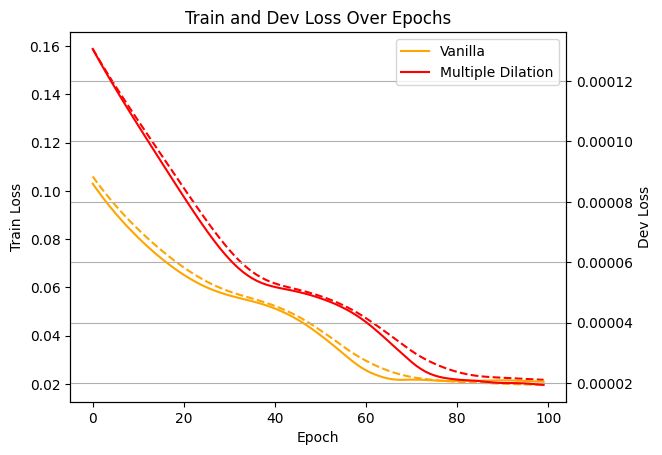

In [79]:
# plot train, dev loss on separate y-axes:
plt.title("Train and Dev Loss Over Epochs")
plt.xlabel("Epoch")
plt.plot([l[0] for l in lossa], label="Train Loss, Vanilla", linestyle='--', color='orange')
plt.plot([l[0] for l in lossb], label="Train Loss, Multiple Dilation", linestyle='--', color='red')
plt.ylabel("Train Loss")
plt.twinx()
plt.plot([l[1].cpu() for l in lossa], label="Vanilla", color='orange')
plt.plot([l[1].cpu() for l in lossb], label="Multiple Dilation", color='red')
plt.ylabel("Dev Loss")
plt.legend(loc="upper right")
plt.grid()
plt.show()

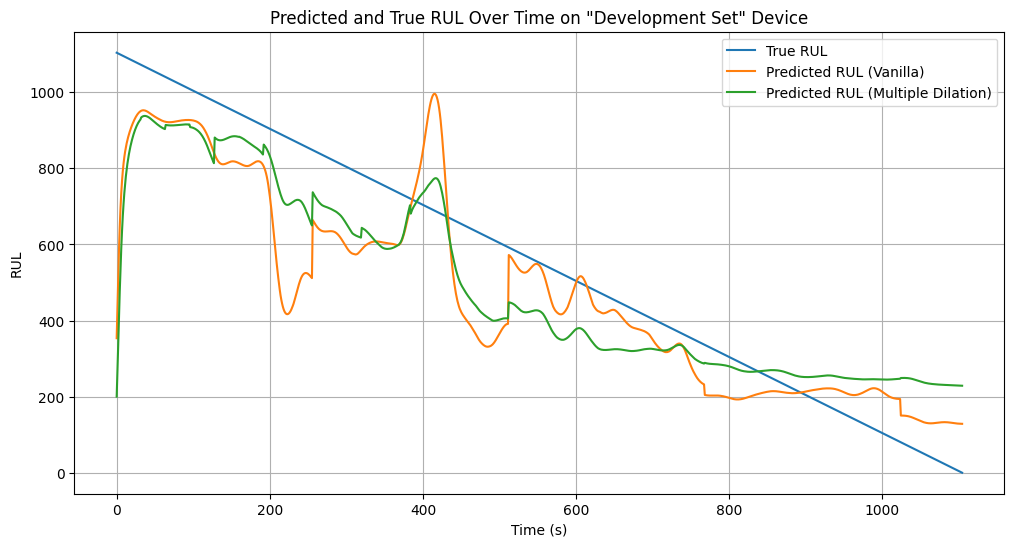

In [80]:
modela.eval()
modelb.eval()
with torch.no_grad():
    esw_dev = torch.tensor(data_dev['Esw'].values, dtype=torch.float32).unsqueeze(0).to(device)
    rth_vt_dev = torch.tensor(data_dev[['Rth', 'Delta_Vt']].values, dtype=torch.float32).unsqueeze(0).to(device)
    
    rula_pred_dev = modela(esw_dev, rth_vt_dev)  # (1, seq_len, 1)
    rulb_pred_dev = modelb(esw_dev, rth_vt_dev)  # (1, seq_len, 1)
    rul_true_dev = data_dev['RUL'].values  # (seq_len,)
    rula_pred_values = rula_pred_dev.squeeze().cpu().numpy() * rul_scale  # (seq_len,)
    rulb_pred_values = rulb_pred_dev.squeeze().cpu().numpy() * rul_scale  # (seq_len,)

# Also plot predicted and true side by side over time
plt.figure(figsize=(12, 6))
plt.plot(data_dev['time'], rul_true_dev, label="True RUL")
plt.plot(data_dev['time'], rula_pred_values, label="Predicted RUL (Vanilla)")
plt.plot(data_dev['time'], rulb_pred_values, label="Predicted RUL (Multiple Dilation)")
plt.xlabel("Time (s)")
plt.ylabel("RUL")
plt.legend()
plt.title("Predicted and True RUL Over Time on \"Development Set\" Device")
plt.grid()
plt.show()